In [272]:
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt

In [273]:
df=pd.read_csv("economic_index.csv")
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [274]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         24 non-null     int64  
 1   year               24 non-null     int64  
 2   month              24 non-null     int64  
 3   interest_rate      24 non-null     float64
 4   unemployment_rate  24 non-null     float64
 5   index_price        24 non-null     int64  
dtypes: float64(2), int64(4)
memory usage: 1.3 KB


In [275]:
df["Unnamed: 0"].isnull().sum()
#df.sort_values("month")

np.int64(0)

In [276]:
df.drop(columns=["Unnamed: 0","year","month"],inplace=True)

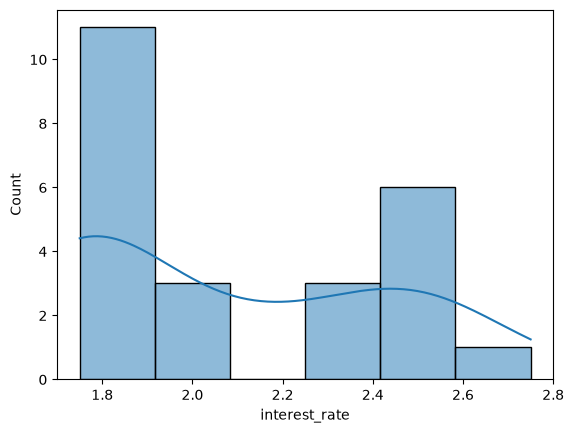

In [277]:
sns.histplot(x="interest_rate",data=df,kde=True)
plt.show()

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

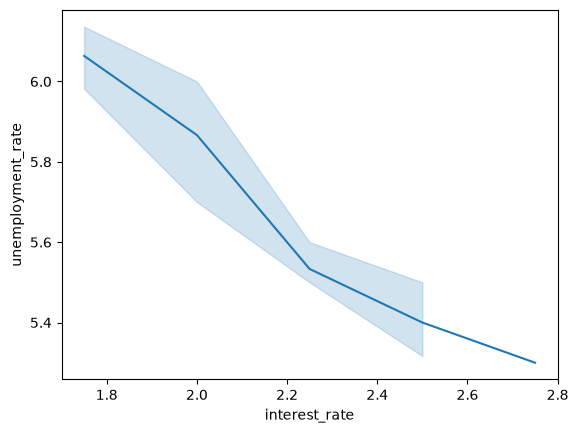

In [278]:
sns.lineplot(x="interest_rate",y="unemployment_rate",data=df)

In [279]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [280]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


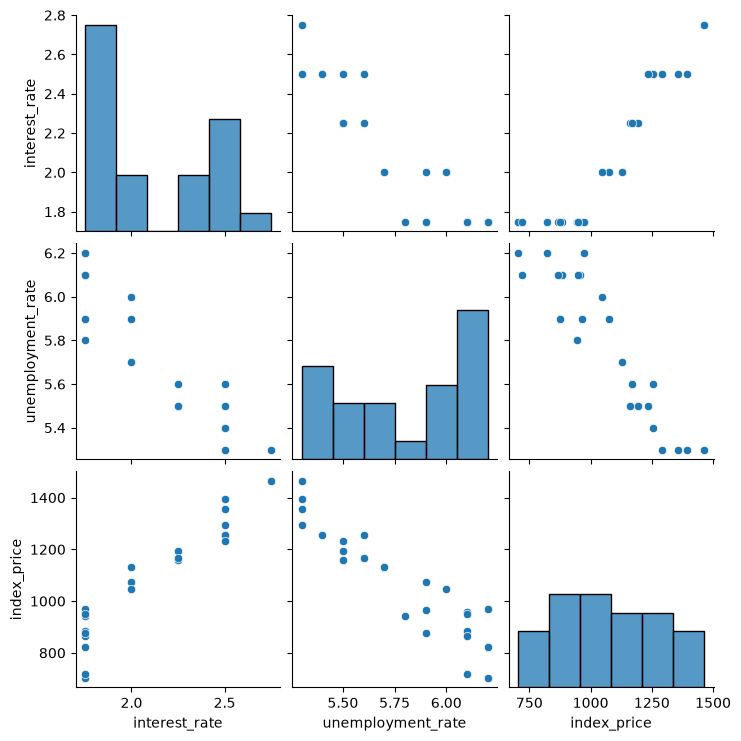

In [281]:
sns.pairplot(df)

In [282]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

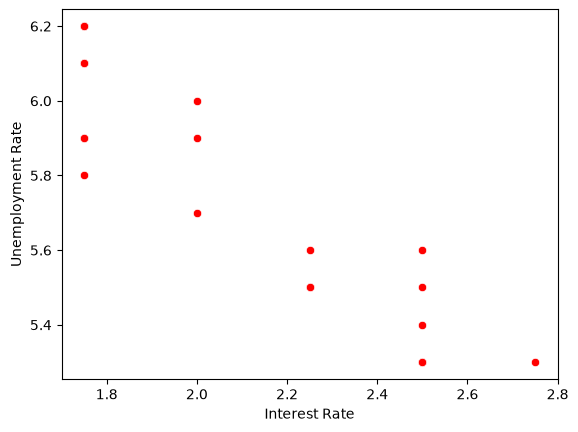

In [283]:
sns.scatterplot(x=df["interest_rate"],y=df["unemployment_rate"],color="r")
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

In [284]:
'''Dependent & Independent Features Separation'''
'''X=pd.DataFrame(columns=['interest_rate','unemployment_rate'],data=df)
Y=pd.DataFrame(columns=['index_price'],data=df)
'''

"X=pd.DataFrame(columns=['interest_rate','unemployment_rate'],data=df)\nY=pd.DataFrame(columns=['index_price'],data=df)\n"

In [285]:
X=df[['interest_rate','unemployment_rate']]
Y=df[['index_price']]

In [286]:
from sklearn.model_selection import train_test_split as tts,cross_val_score as CVS

In [287]:
X_train,X_test,Y_train,Y_test=tts(X,Y,test_size=0.30,random_state=42)

In [288]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [289]:
Scale=StandardScaler()
X_train=Scale.fit_transform(X_train)
X_test=Scale.transform(X_test)

In [290]:
LR=LinearRegression()
LR.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [291]:
y_pred=LR.predict(X_test)

In [292]:
LR.coef_

array([[  96.28689501, -101.57024663]])

In [293]:
LR.intercept_

array([1037.6875])

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [ ]:
MSE=mean_squared_error(Y_test,y_pred)
MAE=mean_absolute_error(Y_test,y_pred)
RMSE=np.sqrt(MSE)

In [ ]:
print(MSE)
print(MAE)
print(RMSE)

5088.329958293995
58.95987629034903
71.33253085580236


In [ ]:
Cross_val=CVS(LR,X_train,Y_train,scoring="neg_mean_squared_error",cv=3)
Cross_val.mean()

np.float64(-8584.447029905594)

Assumptions

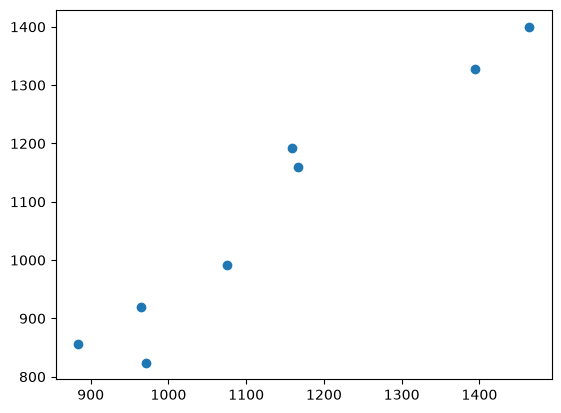

In [295]:
plt.scatter(Y_test,y_pred)

In [296]:
residuals=Y_test-y_pred

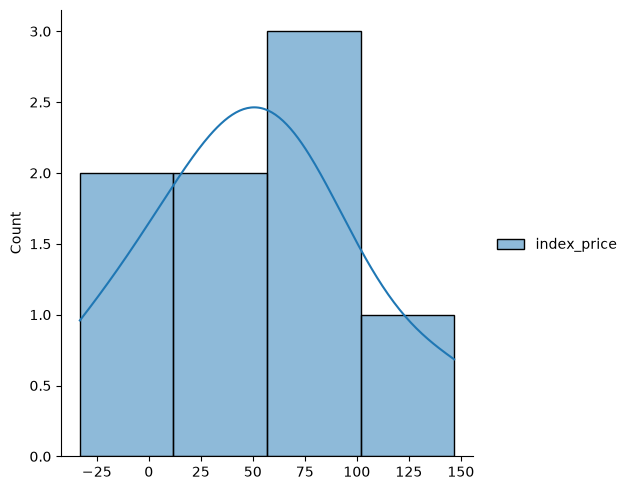

In [297]:
sns.displot(residuals,kde=True)

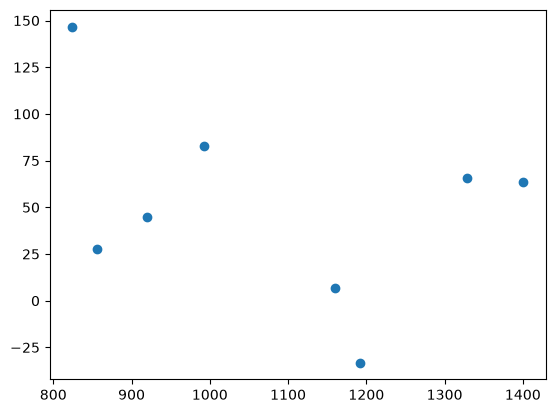

In [300]:
plt.scatter(y_pred,residuals)

In [301]:
import statsmodels.api as sm

In [302]:
model=sm.OLS(Y_train,X_train).fit()

In [304]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.105
Method:                 Least Squares   F-statistic:                             0.2425
Date:                Fri, 03 Jul 2026   Prob (F-statistic):                       0.788
Time:                        13:50:04   Log-Likelihood:                         -133.85
No. Observations:                  16   AIC:                                      271.7
Df Residuals:                      14   BIC:                                      273.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            96.2869    682.952      0.141      0.890   -1368.500    1561.074
x2          -101.5702    682.952     -0.149      0.884   -1566.357    1363.216
==============================================================================
Omnibus:                        0.466   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.792   Jarque-Bera (JB):                0.412
Skew:                          -0.327   Prob(JB):                        0.814
Kurtosis:                       2.563   Cond. No.                         4.70
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [305]:
LR.coef_

array([[  96.28689501, -101.57024663]])